#**Data Acquisition and Generation**#

1. **Seoul city geospatial pixelation**
2. **Collection of PM10 Concentration Data by District in Seoul**
3. **Creation of Distance-Weighted Averaging Features**

**1.Seoul city geospatial pixelation**

1.1. We compiled the latitude, longitude, and area information of the 12 largest urban forests (parks) within Seoul, based on publicly available and reliable sources.

1.2. We collected the geographic coordinates (latitude and longitude) of fine dust monitoring stations for each district, as provided by the Seoul Metropolitan Government’s air quality information system.

1.3. Given the relatively small geographical variation within Seoul, these coordinates were projected onto a 2D pixel grid to enable spatial analysis.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 서울 범위 (대략적인 경계)
lat_min, lat_max = 37.413, 37.715
lon_min, lon_max = 126.734, 127.269

# 위도/경도당 500m 단위 계산
lat_step = 500 / 111000  # 약 0.0045도
lon_step = 500 / (np.cos(np.radians((lat_min + lat_max)/2)) * 111000)  # 약 0.0056도

n_rows = int((lat_max - lat_min) / lat_step)
n_cols = int((lon_max - lon_min) / lon_step)

# 격자 이미지 초기화
image = np.zeros((n_rows, n_cols, 3))  # RGB

In [ ]:
def latlon_to_pixel(lat, lon):
    row = int((lat_max - lat) / lat_step)
    col = int((lon - lon_min) / lon_step)
    return row, col

In [ ]:
import pandas as pd

# 도시숲 리스트
parks = [
    {"name": "월드컵공원", "area": 3471090, "lat": 37.568230, "lon": 126.897243},
    {"name": "남산공원", "area": 2896887, "lat": 37.555711, "lon": 126.992251},
    {"name": "안산도시자연공원", "area": 2088704, "lat": 37.582000, "lon": 126.951000},
    {"name": "올림픽공원", "area": 1450000, "lat": 37.520687, "lon": 127.117111},
    {"name": "서울숲", "area": 1156498, "lat": 37.544625, "lon": 127.039844},
    {"name": "북서울꿈의숲", "area": 662627, "lat": 37.620000, "lon": 127.041000},
    {"name": "보라매공원", "area": 425000, "lat": 37.493234, "lon": 126.917518},
    {"name": "매헌시민의숲", "area": 358992, "lat": 37.471695, "lon": 127.035205},
    {"name": "중랑캠핑숲", "area": 260000, "lat": 37.599600, "lon": 127.096400},
    {"name": "선유도공원", "area": 110400, "lat": 37.542436, "lon": 126.893525},
    {"name": "푸른식물원", "area": 103354, "lat": 37.564214, "lon": 127.001699},
    {"name": "현충원", "area": 1440000, "lat": 37.500598, "lon": 126.972640}
]


# 측정소 리스트
stations = [
    {"name": "강남구", "lat": 37.51796816, "lon": 127.0470598},
    {"name": "강동구", "lat": 37.54500381, "lon": 127.1368198},
    {"name": "강북구", "lat": 37.64793425, "lon": 127.0118697},
    {"name": "강서구", "lat": 37.54465666, "lon": 126.8351713},
    {"name": "관악구", "lat": 37.48064257, "lon": 126.9570309},
    {"name": "광진구", "lat": 37.54594731, "lon": 127.0929507},
    {"name": "구로구", "lat": 37.49884008, "lon": 126.8903092},
    {"name": "금천구", "lat": 37.4523532, "lon": 126.9083015},
    {"name": "노원구", "lat": 37.65748313, "lon": 127.0678641},
    {"name": "도봉구", "lat": 37.6542176, "lon": 127.0290801},
    {"name": "동대문구", "lat": 37.57640498, "lon": 127.028382},
    {"name": "동작구", "lat": 37.48097575, "lon": 126.9716337},
    {"name": "마포구", "lat": 37.55558837, "lon": 126.9055913},
    {"name": "서대문구", "lat": 37.59376657, "lon": 126.9496911},
    {"name": "서초구", "lat": 37.50458542, "lon": 126.9944717},
    {"name": "성동구", "lat": 37.54203238, "lon": 127.0496885},
    {"name": "성북구", "lat": 37.60681328, "lon": 127.0272803},
    {"name": "송파구", "lat": 37.50272901, "lon": 127.0925211},
    {"name": "양천구", "lat": 37.52597518, "lon": 126.8566021},
    {"name": "영등포구", "lat": 37.52596316, "lon": 126.8963671},
    {"name": "용산구", "lat": 37.53485709, "lon": 127.0002687},
    {"name": "은평구", "lat": 37.60987179, "lon": 126.9343249},
    {"name": "종로구", "lat": 37.57206117, "lon": 127.0050313},
    {"name": "중구", "lat": 37.56455419, "lon": 126.9756136},
    {"name": "중랑구", "lat": 37.58491272, "lon": 127.0940363}
]


# 격자 좌표 추가
for park in parks:
    park['x'], park['y'] = latlon_to_pixel(park['lat'], park['lon'])

for station in stations:
    station['x'], station['y'] = latlon_to_pixel(station['lat'], station['lon'])


In [ ]:
print(parks)
print(stations)

[{'name': '월드컵공원', 'area': 3471090, 'lat': 37.56823, 'lon': 126.897243, 'x': 32, 'y': 28}, {'name': '남산공원', 'area': 2896887, 'lat': 37.555711, 'lon': 126.992251, 'x': 35, 'y': 45}, {'name': '안산도시자연공원', 'area': 2088704, 'lat': 37.582, 'lon': 126.951, 'x': 29, 'y': 38}, {'name': '올림픽공원', 'area': 1450000, 'lat': 37.520687, 'lon': 127.117111, 'x': 43, 'y': 67}, {'name': '서울숲', 'area': 1156498, 'lat': 37.544625, 'lon': 127.039844, 'x': 37, 'y': 53}, {'name': '북서울꿈의숲', 'area': 662627, 'lat': 37.62, 'lon': 127.041, 'x': 21, 'y': 54}, {'name': '보라매공원', 'area': 425000, 'lat': 37.493234, 'lon': 126.917518, 'x': 49, 'y': 32}, {'name': '매헌시민의숲', 'area': 358992, 'lat': 37.471695, 'lon': 127.035205, 'x': 54, 'y': 53}, {'name': '중랑캠핑숲', 'area': 260000, 'lat': 37.5996, 'lon': 127.0964, 'x': 25, 'y': 63}, {'name': '선유도공원', 'area': 110400, 'lat': 37.542436, 'lon': 126.893525, 'x': 38, 'y': 28}, {'name': '푸른식물원', 'area': 103354, 'lat': 37.564214, 'lon': 127.001699, 'x': 33, 'y': 47}, {'name': '현충원', 'are

In [ ]:
# DataFrame 변환
df_parks = pd.DataFrame(parks)
df_stations = pd.DataFrame(stations)


# 도시숲 → 초록색
for park in parks:
    r, c = latlon_to_pixel(park["lat"], park["lon"])
    if 0 <= r < n_rows and 0 <= c < n_cols:
        image[r, c, 1] = 1.0  # green

# 측정소 → 빨간색
for station in stations:
    r, c = latlon_to_pixel(station["lat"], station["lon"])
    if 0 <= r < n_rows and 0 <= c < n_cols:
        image[r, c, 0] = 1.0  # red


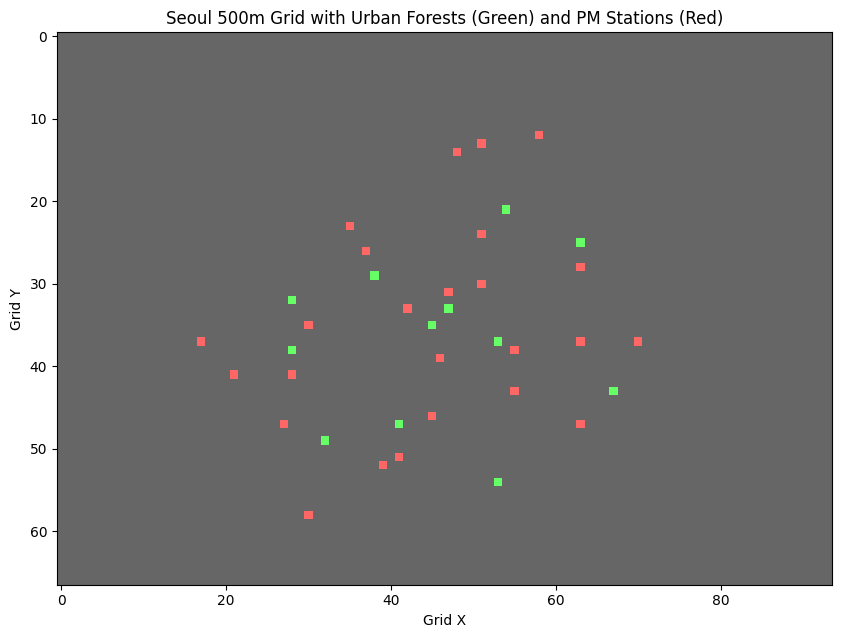

In [ ]:
import matplotlib.pyplot as plt

# 시각화
plt.figure(figsize=(10, 10))
plt.imshow(image, origin='upper', alpha=0.6)
plt.title("Seoul 500m Grid with Urban Forests (Green) and PM Stations (Red)")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.grid(False)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from math import atan2, sin, cos

# 거리 계산 함수
def euclidean_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# 방향 벡터 → sin, cos 변환
def direction_vector(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y1 - y2  # y축 반전
    angle = atan2(-dy, dx)
    return sin(angle), cos(angle)

parks = df_parks.to_dict('records')
stations = df_stations.to_dict('records')

# 결과 저장 리스트
records = []

for station in stations:
    sx, sy = station['x'], station['y']

    # 거리 계산
    df_parks['distance'] = df_parks.apply(
        lambda p: euclidean_distance(sx, sy, p['x'], p['y']), axis=1
    )

    # 가까운 3개 공원
    nearest = df_parks.nsmallest(3, 'distance').copy()

    # 원하는 구조로 행 구성
    row = {'station_name': station['name']}

    for i, (_, park) in enumerate(nearest.iterrows(), start=1):
        dir_sin, dir_cos = direction_vector(sx, sy, park['x'], park['y'])
        row[f'park{i}_name'] = park['name']
        row[f'park{i}_dir_sin'] = dir_sin
        row[f'park{i}_dir_cos'] = dir_cos
        row[f'park{i}_distance'] = park['distance']
        row[f'park{i}_area'] = park['area']

    records.append(row)

# 결과 DataFrame
df_final = pd.DataFrame(records)

In [ ]:
print(df_final)

   station_name park1_name  park1_dir_sin  park1_dir_cos  park1_distance  \
0           강남구        서울숲  -3.162278e-01      -0.948683        6.324555   
1           강동구      올림픽공원  -4.472136e-01       0.894427        6.708204   
2           강북구     북서울꿈의숲   6.507914e-01       0.759257        9.219544   
3           강서구      선유도공원   9.958932e-01       0.090536       11.045361   
4           관악구        현충원   3.713907e-01      -0.928477        5.385165   
5           광진구      올림픽공원   5.547002e-01       0.832050        7.211103   
6           구로구      보라매공원   9.284767e-01       0.371391        5.385165   
7           금천구      보라매공원   2.169305e-01      -0.976187        9.219544   
8           노원구     북서울꿈의숲  -4.061385e-01       0.913812        9.848858   
9           도봉구     북서울꿈의숲   3.511234e-01       0.936329        8.544004   
10         동대문구      푸른식물원  -8.000000e-01       0.600000        5.000000   
11          동작구        현충원   1.224647e-16      -1.000000        4.000000   
12          

**2.Collection of PM10 Concentration Data by District in Seoul**

1. PM10 concentration data for each district (gu) in Seoul was collected through API calls.

2. Based on the timestamp of each API call, additional derived features such as date-time (year, month, day, hour) and season were generated.

In [ ]:
from datetime import datetime, timedelta

start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 12, 31)
target_weekdays = [0, 2, 4, 5]  # 월, 수, 금, 토
target_hours = ['0300', '0800', '1400', '1800']

timestamps = []

current = start_date
while current <= end_date:
    if current.weekday() in target_weekdays:
        for hour in target_hours:
            timestamps.append(current.strftime('%Y%m%d') + hour)
    current += timedelta(days=1)

print("📌 앞 5개:", timestamps[:5])
print("📌 마지막 10개:", timestamps[-10:])
print(f"✅ 총 {len(timestamps)}개의 타임스탬프가 생성되었습니다.")

📌 앞 5개: ['202401010300', '202401010800', '202401011400', '202401011800', '202401030300']
📌 마지막 10개: ['202412271400', '202412271800', '202412280300', '202412280800', '202412281400', '202412281800', '202412300300', '202412300800', '202412301400', '202412301800']
✅ 총 836개의 타임스탬프가 생성되었습니다.


In [ ]:
import requests
import pandas as pd
import xml.etree.ElementTree as ET

# 1. API 설정
SERVICE_KEY = '446e594254676b61373773624c536d'
BASE_URL = 'http://openAPI.seoul.go.kr:8088'

# 2. 호출 함수
def get_air_quality_data(date_string):
    endpoint = f'{BASE_URL}/{SERVICE_KEY}/xml/TimeAverageAirQuality/1/25/{date_string}'
    response = requests.get(endpoint)

    if response.status_code == 200:
        try:
            root = ET.fromstring(response.content)
            rows = root.findall('.//row')
            data = []
            for row in rows:
                record = {}
                for elem in row:
                    record[elem.tag] = elem.text
                record['MSRDT'] = date_string  # 수동으로 날짜 추가
                data.append(record)
            return data
        except ET.ParseError as e:
            print(f"XML 파싱 오류: {e} | 날짜: {date_string}")
            return []
    else:
        print(f"API 실패 {response.status_code} | 날짜: {date_string}")
        return []


# 반복 수집
all_data = []

for ts in timestamps:
    records = get_air_quality_data(ts)
    if records:
        all_data.extend(records)

# DataFrame으로 저장
df = pd.DataFrame(all_data)

# 6. 확인 및 저장
print(df.head())
print(f"✅ 총 {len(df)}개의 측정 기록이 수집되었습니다.")

KeyboardInterrupt: 

In [ ]:
"""df.to_csv("/content/drive/MyDrive/DS teamproj/air_quality_2024_sample.csv", index=False)"""

In [ ]:
import pandas as pd

# 대기오염 데이터
df_api = pd.read_csv('/content/drive/MyDrive/DS teamproj/data/air_quality_2024_sample.csv')

"""df_api = df"""

# season 계산 함수
def get_season(msrdt):
    month = int(str(msrdt)[4:6])  # YYYYMMDDHH → MM
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "fall"

# df_final: 이전에 저장한 station + park 정보
"""df_station_parks = pd.read_csv("/content/drive/MyDrive/DS teamproj/data/station_nearest_3parks_vector.csv")"""

df_station_parks= df_final

# 필요한 칼럼 선택 및 병합 준비
df_api_filtered = df_api[['MSRSTE_NM', 'MSRDT', 'PM10']].copy()
df_api_filtered.rename(columns={'MSRSTE_NM': 'station_name', 'MSRDT': 'ymdt', 'PM10': 'pm10'}, inplace=True)

# 계절 추가
df_api_filtered['season'] = df_api_filtered['ymdt'].apply(get_season)

# ID 부여
df_api_filtered['id'] = range(1, len(df_api_filtered) + 1)

# 측정소별 도시숲 정보 병합
df_merged = pd.merge(df_api_filtered, df_station_parks, on='station_name', how='left')

# 최종 순서 정렬 (원하는 순서로 열 정렬)
cols = ['id', 'station_name', 'ymdt', 'season'] + \
       [f'park{i}_{attr}' for i in range(1, 4) for attr in ['name', 'dir_sin', 'dir_cos', 'distance', 'area']] + \
       ['pm10']

df_final_output = df_merged[cols]

"""
# 저장
df_final_output.to_csv("/content/drive/MyDrive/DS teamproj/final_pm10_with_urbanforest.csv", index=False)
"""


'\n# 저장\ndf_final_output.to_csv("/content/drive/MyDrive/DS teamproj/final_pm10_with_urbanforest.csv", index=False)\n'

In [ ]:
df = df_final_output

# 시간 파생 변수 생성
df["timestamp"] = pd.to_datetime(df["ymdt"], format="%Y%m%d%H%M")
df["hour"] = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month
df["weekday"] = df["timestamp"].dt.weekday

<ipython-input-14-3727044030>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["timestamp"] = pd.to_datetime(df["ymdt"], format="%Y%m%d%H%M")
<ipython-input-14-3727044030>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hour"] = df["timestamp"].dt.hour
<ipython-input-14-3727044030>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

In [ ]:
df.head(10)

,id,station_name,ymdt,season,park1_name,park1_dir_sin,park1_dir_cos,park1_distance,park1_area,park2_name,...,park3_name,park3_dir_sin,park3_dir_cos,park3_distance,park3_area,pm10,timestamp,hour,month,weekday
0,1,강남구,202401010300,winter,서울숲,-0.316228,-0.948683,6.324555,1156498,매헌시민의숲,...,올림픽공원,1.000000e+00,6.123234e-17,12.000000,1450000,21.0,2024-01-01 03:00:00,3,1,0
1,2,강동구,202401010300,winter,올림픽공원,-0.447214,0.894427,6.708204,1450000,중랑캠핑숲,...,서울숲,-1.000000e+00,6.123234e-17,17.000000,1156498,20.0,2024-01-01 03:00:00,3,1,0
2,3,강북구,202401010300,winter,북서울꿈의숲,0.650791,0.759257,9.219544,662627,안산도시자연공원,...,중랑캠핑숲,8.064050e-01,5.913637e-01,18.601075,260000,16.0,2024-01-01 03:00:00,3,1,0
3,4,강서구,202401010300,winter,선유도공원,0.995893,0.090536,11.045361,110400,월드컵공원,...,보라매공원,7.808688e-01,6.246950e-01,19.209373,425000,53.0,2024-01-01 03:00:00,3,1,0
4,5,관악구,202401010300,winter,현충원,0.371391,-0.928477,5.385165,1440000,보라매공원,...,매헌시민의숲,9.899495e-01,1.414214e-01,14.142136,358992,54.0,2024-01-01 03:00:00,3,1,0
5,6,광진구,202401010300,winter,올림픽공원,0.554700,0.832050,7.211103,1450000,서울숲,...,중랑캠핑숲,1.224647e-16,-1.000000e+00,12.000000,260000,17.0,2024-01-01 03:00:00,3,1,0
6,7,구로구,202401010300,winter,보라매공원,0.928477,0.371391,5.385165,425000,선유도공원,...,현충원,1.000000e+00,6.123234e-17,14.000000,1440000,37.0,2024-01-01 03:00:00,3,1,0
7,8,금천구,202401010300,winter,보라매공원,0.216930,-0.976187,9.219544,425000,현충원,...,선유도공원,-9.950372e-02,-9.950372e-01,20.099751,110400,31.0,2024-01-01 03:00:00,3,1,0
8,9,노원구,202401010300,winter,북서울꿈의숲,-0.406138,0.913812,9.848858,662627,중랑캠핑숲,...,푸른식물원,-4.640070e-01,8.858315e-01,23.706539,103354,28.0,2024-01-01 03:00:00,3,1,0
9,10,도봉구,202401010300,winter,북서울꿈의숲,0.351123,0.936329,8.544004,662627,중랑캠핑숲,...,푸른식물원,-1.961161e-01,9.805807e-01,20.396078,103354,NaN,2024-01-01 03:00:00,3,1,0


**3. Creation of Distance-Weighted Averaging Features**
1. Since urban forests located closer to monitoring stations are likely to have a greater impact on fine dust concentration, we created features by applying distance-weighted averaging based on both the distance from each station to nearby urban forests and the forest area.

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from math import exp
import requests

"""df = pd.read_csv('/content/drive/MyDrive/DS teamproj/final_pm10_with_urbanforest.csv')"""

# 거리감쇠 기반 가중 평균 feature 생성
def exp_decay_weight(area, distance, k=0.3):
    return area * np.exp(-k * distance)

w1 = exp_decay_weight(df["park1_area"], df["park1_distance"])
w2 = exp_decay_weight(df["park2_area"], df["park2_distance"])
w3 = exp_decay_weight(df["park3_area"], df["park3_distance"])
total_w = w1 + w2 + w3

df["weighted_area"] = (df["park1_area"] * w1 + df["park2_area"] * w2 + df["park3_area"] * w3) / total_w
df["weighted_distance"] = (df["park1_distance"] * w1 + df["park2_distance"] * w2 + df["park3_distance"] * w3) / total_w



<ipython-input-16-3658424091>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["weighted_area"] = (df["park1_area"] * w1 + df["park2_area"] * w2 + df["park3_area"] * w3) / total_w
<ipython-input-16-3658424091>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["weighted_distance"] = (df["park1_distance"] * w1 + df["park2_distance"] * w2 + df["park3_distance"] * w3) / total_w


**Collection of Meteorological Data**

1. We utilized daily meteorological statistics for Seoul provided by the Korea Meteorological Administration.
The dataset includes wind direction, wind speed, precipitation, surface pressure, temperature, and relative humidity.
2. As fine dust concentration is heavily influenced by weather conditions, we used daily summary data instead of hourly data to place greater emphasis on the impact of urban forests.

In [ ]:
unique_times = df['ymdt'].drop_duplicates().tolist()
print(unique_times)

[202401010300, 202401010800, 202401011400, 202401011800, 202401030300, 202401030800, 202401031400, 202401031800, 202401050300, 202401050800, 202401051400, 202401051800, 202401060300, 202401060800, 202401061400, 202401061800, 202401080300, 202401080800, 202401081400, 202401081800, 202401100300, 202401100800, 202401101400, 202401101800, 202401120300, 202401120800, 202401121400, 202401121800, 202401130300, 202401130800, 202401131400, 202401131800, 202401150300, 202401150800, 202401151400, 202401151800, 202401170300, 202401170800, 202401171400, 202401171800, 202401190300, 202401190800, 202401191400, 202401191800, 202401200300, 202401200800, 202401201400, 202401201800, 202401220300, 202401220800, 202401221400, 202401221800, 202401240300, 202401240800, 202401241400, 202401241800, 202401260300, 202401260800, 202401261400, 202401261800, 202401270300, 202401270800, 202401271400, 202401271800, 202401290300, 202401290800, 202401291400, 202401291800, 202401310300, 202401310800, 202401311400, 20240

In [ ]:
def get_weather(dt):
    import requests
    from numpy import nan
    base_date_time = dt
    url = f'https://apihub.kma.go.kr/api/typ01/url/kma_sfctm2.php?tm={base_date_time}&stn=108&help=0&authKey=YS6kErh3SmeupBK4d2pnjg'

    try:
        response = requests.get(url)
        lines = response.text.splitlines()

        data_line = next(line for line in lines if not line.startswith('#'))
        values = data_line.split()

        def safe_float(val):
            try:
                f = float(val)
                return nan if f == -9.0 else f
            except:
                return nan

        def rain_float(val):
            try:
                f = float(val)
                return 0.0 if f == -9.0 else f  # 🌧️ -9.0은 비가 안 온 것
            except:
                return nan

        return {
            'wind_dir': safe_float(values[2]),
            'wind_spd': safe_float(values[3]),
            'rain': rain_float(values[15]),
            'hPA': safe_float(values[7]),
            'temperature': safe_float(values[11]),
            'humidity': safe_float(values[13]),
        }

    except Exception as e:
        print(f"⚠️ API error for {dt}: {e}")
        return {
            'wind_dir': nan,
            'wind_spd': nan,
            'rain': nan,
            'hPA': nan,
            'temperature': nan,
            'humidity': nan
        }

In [ ]:
# 각 날짜시간에 대해 API 호출해서 결과 저장
weather_dict = {}
for dt in unique_times:
    weather_dict[dt] = get_weather(dt)

# 원래 df에 날짜시간 기준으로 매핑 (broadcast)
weather_df = pd.DataFrame.from_dict(weather_dict, orient='index')
weather_df.columns = ['wind_dir', 'wind_spd', 'rain', 'hPA', 'temperature', 'humidity']
weather_df['ymdt'] = weather_df.index

# 원래 df에 병합
df = df.merge(weather_df, on='ymdt', how='left')

In [ ]:
df.to_csv('/content/drive/MyDrive/DS teamproj/train.csv', index=False)

#**Data processing**#

1. **Missing Value Handling**

* Rows with missing values in pm10 and wind_dir due to API request failures were removed from the dataset.
2. **Input and Output Variable Definition**

* The input and output variables were defined for model training and evaluation.
3. **Train-Test Split**
* The dataset was divided into training and test sets to enable model validation.
4. **Scaling the Training Set**
* A scaling function was fitted using only the training set, and the resulting parameters were saved for future application.

In [ ]:
"""df = pd.read_csv("/content/drive/MyDrive/DS teamproj/train.csv")"""

In [ ]:
from sklearn.model_selection import train_test_split


# 'wind_dir'에 NaN이 있는 행 제거
df_clean_0 = df.dropna(subset=["pm10"])
df_clean_1 = df_clean_0.dropna(subset=['wind_dir'])

# 사용할 feature 구성
drop_cols = [
    "id", "pm10", "ymdt",
    "park1_name", "park2_name", "park3_name",
    "park1_area", "park2_area", "park3_area",
    "park1_distance", "park2_distance", "park3_distance", "timestamp"
]
X = df_clean_1.drop(columns=drop_cols)
y = df_clean_1["pm10"]

# 범주형 변수 인코딩
X = pd.get_dummies(X, columns=["station_name", "season"], drop_first=False)

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

"""df_clean_1.to_csv("/content/drive/MyDrive/DS teamproj/train_clean.csv", index=False)"""

'df_clean_1.to_csv("/content/drive/MyDrive/DS teamproj/train_clean.csv", index=False)'

In [ ]:
from sklearn.preprocessing import StandardScaler


# train 데이터용 스케일링 함수 (fit + transform)
def Scaling_fit(X):
    scaler = StandardScaler()
    binary_columns = [col for col in X.columns if X[col].dropna().isin([0, 1]).all()]
    continuous_columns = [col for col in X.columns if col not in binary_columns]

    X_scaled = scaler.fit_transform(X[continuous_columns])
    X_scaled = pd.DataFrame(X_scaled, columns=continuous_columns, index=X.index)
    X_final = pd.concat([X_scaled, X[binary_columns]], axis=1)
    return X_final, scaler, continuous_columns, binary_columns

# test 데이터용 스케일링 함수 (transform 전용)
def Scaling_transform(X, scaler, continuous_columns, binary_columns):
    X_scaled = scaler.transform(X[continuous_columns])
    X_scaled = pd.DataFrame(X_scaled, columns=continuous_columns, index=X.index)
    X_final = pd.concat([X_scaled, X[binary_columns]], axis=1)
    # 원본 컬럼 순서 유지
    X_final = X_final[X.columns]
    return X_final

In [ ]:
X_train, scaler, continuous_columns, binary_columns = Scaling_fit(X_train)
X_test = Scaling_transform(X_test, scaler, continuous_columns, binary_columns)

In [ ]:
import joblib

# 스케일러 저장
joblib.dump(scaler, 'scaler.pkl')

# 스케일러 불러오기
scaler = joblib.load('scaler.pkl')


#**Modeling**#

* **Base Models**: XGBoost, CatBoost, Random Forest, and Multi-Layer Perceptron (MLP)

* **Meta Model**: XGBoost

Each base model was individually tuned using Grid Search to identify the optimal hyperparameters. Based on these results, the base models were constructed with their respective best parameters. Subsequently, only the meta model (XGBoost) was further tuned to optimize the overall performance of the stacked ensemble.

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 22.4 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor


# 1. XGBoost 튜닝
xgb_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.04, 0.05, 0.06],
    'max_depth': [4, 5, 6],  # 추가
    'subsample': [0.8, 1.0],  # 추가
}

xgb = GridSearchCV(XGBRegressor(objective='reg:squarederror', random_state=42), xgb_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
xgb.fit(X_train, y_train)
xgb_best = xgb.best_estimator_

# 2. CatBoost 튜닝
cat_grid = {
    'learning_rate': [0.04, 0.05, 0.06],
    'depth': [5, 6, 7],
    'iterations': [200, 300],  # 추가
    'l2_leaf_reg': [1, 3, 5],  # 정규화 추가
}

cat = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), cat_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
cat.fit(X_train, y_train)
cat_best = cat.best_estimator_

# 3. RandomForest 튜닝
rf_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 12, 14],
    'min_samples_split': [2, 5],  # 추가
    'min_samples_leaf': [1, 2],   # 추가
}

rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
rf.fit(X_train, y_train)
rf_best = rf.best_estimator_

# 4. MLP 튜닝
mlp_grid = {
    'hidden_layer_sizes': [(128, 64, 32), (64, 32, 16), (32, 16)],
    'learning_rate_init': [0.003, 0.005, 0.007],
    'activation': ['relu', 'tanh'],  # 추가
    'alpha': [0.0001, 0.001],  # 정규화
    'max_iter': [300],
}

mlp = GridSearchCV(MLPRegressor(random_state=42), mlp_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
mlp.fit(X_train, y_train)
mlp_best = mlp.best_estimator_

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits


In [ ]:
print("=== Best Parameters and Score for Each Model ===\n")

print("1. XGBoost")
print("Best Params:", xgb.best_params_)
print("Best CV Score (Negative RMSE):", xgb.best_score_)
print()

print("2. CatBoost")
print("Best Params:", cat.best_params_)
print("Best CV Score (Negative RMSE):", cat.best_score_)
print()

print("3. RandomForest")
print("Best Params:", rf.best_params_)
print("Best CV Score (Negative RMSE):", rf.best_score_)
print()

print("4. MLP")
print("Best Params:", mlp.best_params_)
print("Best CV Score (Negative RMSE):", mlp.best_score_)
print()

=== Best Parameters and Score for Each Model ===

1. XGBoost
Best Params: {'learning_rate': 0.06, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.8}
Best CV Score (Negative RMSE): -6.334042821676243

2. CatBoost
Best Params: {'depth': 7, 'iterations': 300, 'l2_leaf_reg': 1, 'learning_rate': 0.06}
Best CV Score (Negative RMSE): -8.007009437591142

3. RandomForest
Best Params: {'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score (Negative RMSE): -6.615321509062074

4. MLP
Best Params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.003, 'max_iter': 300}
Best CV Score (Negative RMSE): -7.068204342377325



In [ ]:
from sklearn.ensemble import StackingRegressor

# 튜닝된 base 모델 사용
base_models = [
    ('xgb', xgb_best),
    ('cat', cat_best),
    ('rf', rf_best),
    ('mlp', mlp_best)
]

# 메타 모델만 그리드 서치
meta_grid = {
    'n_estimators': [100],
    'learning_rate': [0.03, 0.05]
}
meta_model = GridSearchCV(XGBRegressor(objective='reg:squarederror', random_state=42), meta_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
meta_model.fit(X_train, y_train)
meta_best = meta_model.best_estimator_

# 최종 스태킹 모델 구성
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_best,
    passthrough=True,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)


Fitting 3 folds for each of 2 candidates, totalling 6 fits


StackingRegressor(estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_ra...
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None,
                                               max_depth=None, max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=100, n_jobs=None,
                                               num_parallel_tree=None,
                                               random_state=42, ...),
                  n_jobs=-1, passthrough=True)

In [ ]:
import joblib

# 저장 경로 (구글 드라이브 마운트 필요)
model_path = '/content/drive/MyDrive/stacking_model_final_average.pkl'

# 모델 저장\

joblib.dump(stacking_model, model_path)
print("✅ 최종 스태킹 모델이 저장되었습니다:", model_path)


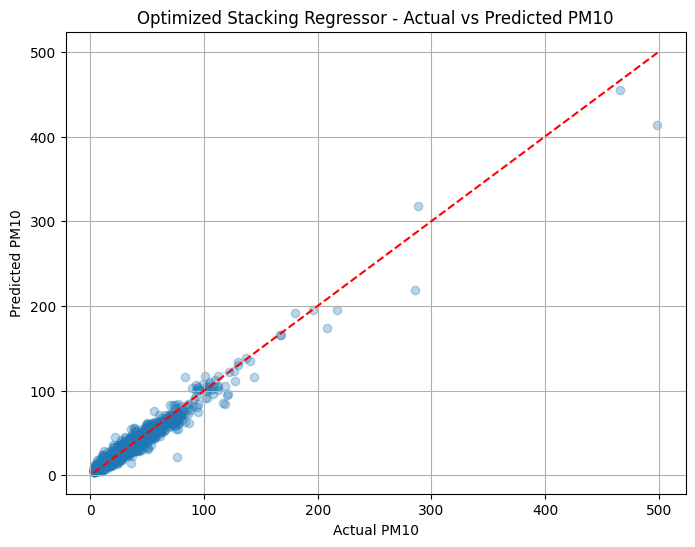

RMSE: 5.793936533633
MAE: 3.6245381646189263
R2 Score: 0.9548395817349666
MRE (Mean Relative Error): 4.83%


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 예측
y_pred = stacking_model.predict(X_test)

# RMSE 수동 계산
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 기타 지표
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# MRE 계산 (0으로 나눔 방지 포함)
relative_error = np.where(y_test != 0, (y_pred - y_test) / y_test, 0)
mre = np.mean(relative_error) * 100

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual PM10")
plt.ylabel("Predicted PM10")
plt.title("Optimized Stacking Regressor - Actual vs Predicted PM10")
plt.grid(True)
plt.show()

# 출력
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
print("MRE (Mean Relative Error): {:.2f}%".format(mre))

In [ ]:
print(X_train.columns)

Index(['park1_dir_sin', 'park1_dir_cos', 'park2_dir_sin', 'park2_dir_cos',
       'park3_dir_sin', 'park3_dir_cos', 'hour', 'month', 'weekday',
       'weighted_area', 'weighted_distance', 'wind_dir', 'wind_spd', 'rain',
       'hPA', 'temperature', 'humidity', 'station_name_강남구',
       'station_name_강동구', 'station_name_강북구', 'station_name_강서구',
       'station_name_관악구', 'station_name_광진구', 'station_name_구로구',
       'station_name_금천구', 'station_name_노원구', 'station_name_도봉구',
       'station_name_동대문구', 'station_name_동작구', 'station_name_마포구',
       'station_name_서대문구', 'station_name_서초구', 'station_name_성동구',
       'station_name_성북구', 'station_name_송파구', 'station_name_양천구',
       'station_name_영등포구', 'station_name_용산구', 'station_name_은평구',
       'station_name_종로구', 'station_name_중구', 'station_name_중랑구',
       'season_fall', 'season_spring', 'season_summer', 'season_winter'],
      dtype='object')


#**New location recommendation**#

To identify potential locations for new urban forests, seven hypothetical sites were generated. These candidate sites were selected based on the following criteria:

* **Direction**: All sites were placed in the west direction, which was found to have the greatest potential for reducing PM10 concentrations.
* **Spatial Gap**: Areas lacking sufficient existing forest coverage were prioritized.
* **Area**: The size of each hypothetical forest was set to 100,000 square meters, matching the smallest area among existing urban forests.


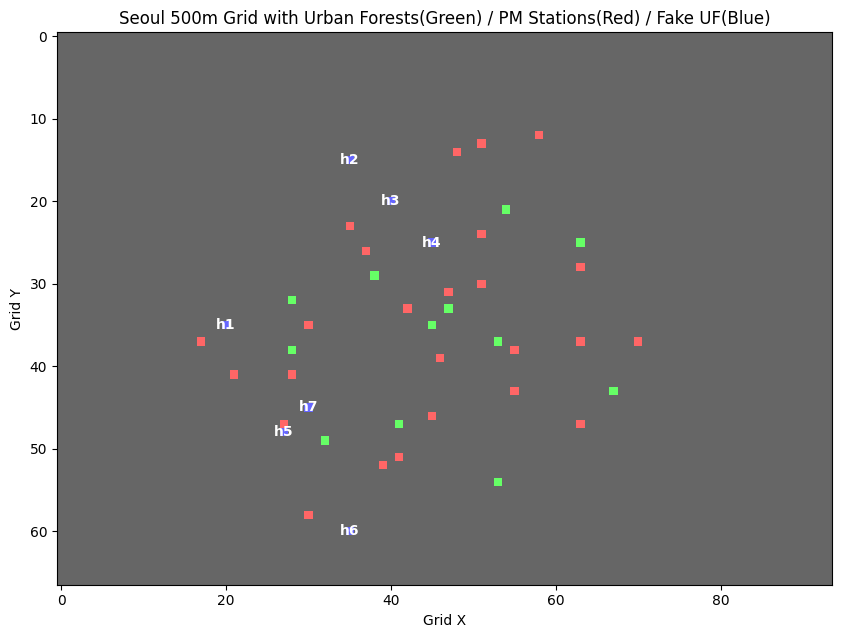

In [ ]:
# 여기서부터 실제 데이터에 사용한 가상 도시숲인데,
# 좌표는 지도와 저희 픽셀표현 기반으로 서쪽에 있으면서, 도시숲이 부족한 곳을 리스트업 했습니다.
# 면적은 실제 도시숲 중 가장 작은 도시숲 기준으로 비슷하게 만들었습니다.
# 이유는 서울에 새로운 도시숲을 조성할 공간이 크지 않을 거라 생각했기 때문입니다.

fk_hm_park = [
    {'name': 'h1', 'x':20, 'y':35, 'area': 100000},
    {'name': 'h2', 'x':35, 'y':15, 'area': 100000},
    {'name': 'h3', 'x':40, 'y':20, 'area': 100000},
    {'name': 'h4', 'x':45, 'y':25, 'area': 100000},
    {'name': 'h5', 'x':27, 'y':48, 'area': 100000},
    {'name': 'h6', 'x':35, 'y':60, 'area': 100000},
    {'name': 'h7', 'x':30, 'y':45, 'area': 100000}
              ]

# 도시숲 → 초록색
for park in parks:
    r, c = latlon_to_pixel(park["lat"], park["lon"])
    if 0 <= r < n_rows and 0 <= c < n_cols:
        image[r, c, 1] = 1.0  # green

# 측정소 → 빨간색
for station in stations:
    r, c = latlon_to_pixel(station["lat"], station["lon"])
    if 0 <= r < n_rows and 0 <= c < n_cols:
        image[r, c, 0] = 1.0  # red

# 가상도시숲 → 노란색
for fk in fk_hm_park:
    r, c = fk['y'], fk['x']
    if 0 <= r < n_rows and 0 <= c < n_cols:
        image[r, c, 2] = 1.0  # red  # 파란색

import matplotlib.pyplot as plt

# 시각화
plt.figure(figsize=(10, 10))
plt.imshow(image, origin='upper', alpha=0.6)
plt.title("Seoul 500m Grid with Urban Forests(Green) / PM Stations(Red) / Fake UF(Blue)")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")

for park in fk_hm_park:
    x = park['x']
    y = park['y']
    name = park['name']
    plt.text(x, y, name, color='white', fontsize=10, ha='center', va='center', weight='bold')

plt.grid(False)
plt.show()

In [ ]:
# 측정소 데이터
stations = [
    {'name': '강남구', 'lat': 37.51796816, 'lon': 127.0470598, 'x': 43, 'y': 55},
    {'name': '강동구', 'lat': 37.54500381, 'lon': 127.1368198, 'x': 37, 'y': 70},
    {'name': '강북구', 'lat': 37.64793425, 'lon': 127.0118697, 'x': 14, 'y': 48},
    {'name': '강서구', 'lat': 37.54465666, 'lon': 126.8351713, 'x': 37, 'y': 17},
    {'name': '관악구', 'lat': 37.48064257, 'lon': 126.9570309, 'x': 52, 'y': 39},
    {'name': '광진구', 'lat': 37.54594731, 'lon': 127.0929507, 'x': 37, 'y': 63},
    {'name': '구로구', 'lat': 37.49884008, 'lon': 126.8903092, 'x': 47, 'y': 27},
    {'name': '금천구', 'lat': 37.4523532, 'lon': 126.9083015, 'x': 58, 'y': 30},
    {'name': '노원구', 'lat': 37.65748313, 'lon': 127.0678641, 'x': 12, 'y': 58},
    {'name': '도봉구', 'lat': 37.6542176, 'lon': 127.0290801, 'x': 13, 'y': 51},
    {'name': '동대문구', 'lat': 37.57640498, 'lon': 127.028382, 'x': 30, 'y': 51},
    {'name': '동작구', 'lat': 37.48097575, 'lon': 126.9716337, 'x': 51, 'y': 41},
    {'name': '마포구', 'lat': 37.55558837, 'lon': 126.9055913, 'x': 35, 'y': 30},
    {'name': '서대문구', 'lat': 37.59376657, 'lon': 126.9496911, 'x': 26, 'y': 37},
    {'name': '서초구', 'lat': 37.50458542, 'lon': 126.9944717, 'x': 46, 'y': 45},
    {'name': '성동구', 'lat': 37.54203238, 'lon': 127.0496885, 'x': 38, 'y': 55},
    {'name': '성북구', 'lat': 37.60681328, 'lon': 127.0272803, 'x': 24, 'y': 51},
    {'name': '송파구', 'lat': 37.50272901, 'lon': 127.0925211, 'x': 47, 'y': 63},
    {'name': '양천구', 'lat': 37.52597518, 'lon': 126.8566021, 'x': 41, 'y': 21},
    {'name': '영등포구', 'lat': 37.52596316, 'lon': 126.8963671, 'x': 41, 'y': 28},
    {'name': '용산구', 'lat': 37.53485709, 'lon': 127.0002687, 'x': 39, 'y': 46},
    {'name': '은평구', 'lat': 37.60987179, 'lon': 126.9343249, 'x': 23, 'y': 35},
    {'name': '종로구', 'lat': 37.57206117, 'lon': 127.0050313, 'x': 31, 'y': 47},
    {'name': '중구', 'lat': 37.56455419, 'lon': 126.9756136, 'x': 33, 'y': 42},
    {'name': '중랑구', 'lat': 37.58491272, 'lon': 127.0940363, 'x': 28, 'y': 63}
]

# 기존 도시숲 데이터
parks = [{'name': '월드컵공원', 'area': 3471090, 'lat': 37.56823, 'lon': 126.897243, 'x': 32, 'y': 28}, {'name': '남산공원', 'area': 2896887, 'lat': 37.555711, 'lon': 126.992251, 'x': 35, 'y': 45}, {'name': '안산도시자연공원', 'area': 2088704, 'lat': 37.582, 'lon': 126.951, 'x': 29, 'y': 38}, {'name': '올림픽공원', 'area': 1450000, 'lat': 37.520687, 'lon': 127.117111, 'x': 43, 'y': 67}, {'name': '서울숲', 'area': 1156498, 'lat': 37.544625, 'lon': 127.039844, 'x': 37, 'y': 53}, {'name': '북서울꿈의숲', 'area': 662627, 'lat': 37.62, 'lon': 127.041, 'x': 21, 'y': 54}, {'name': '보라매공원', 'area': 425000, 'lat': 37.493234, 'lon': 126.917518, 'x': 49, 'y': 32}, {'name': '매헌시민의숲', 'area': 358992, 'lat': 37.471695, 'lon': 127.035205, 'x': 54, 'y': 53}, {'name': '중랑캠핑숲', 'area': 260000, 'lat': 37.5996, 'lon': 127.0964, 'x': 25, 'y': 63}, {'name': '선유도공원', 'area': 110400, 'lat': 37.542436, 'lon': 126.893525, 'x': 38, 'y': 28}, {'name': '푸른식물원', 'area': 103354, 'lat': 37.564214, 'lon': 127.001699, 'x': 33, 'y': 47}, {'name': '현충원', 'area': 1440000, 'lat': 37.500598, 'lon': 126.97264, 'x': 47, 'y': 41}]

In [ ]:
# 기존 도시숲 데이터에 가상 도시숲을 하나씩 추가하는 코드
from math import atan2, sin, cos

# 거리 계산 함수
def euclidean_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# 방향 벡터 → sin, cos 변환
def direction_vector(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y1 - y2  # y축 반전
    angle = atan2(-dy, dx)
    return sin(angle), cos(angle)

added_fks = {}

for i, fk in enumerate(fk_hm_park, start=1):

    # DataFrame → dict 리스트
    df_parks = pd.DataFrame(parks).drop(columns=['lat', 'lon'])
    df_stations = pd.DataFrame(stations)

    df_parks = pd.concat([df_parks, pd.DataFrame([fk])], ignore_index=True)
    added_fks[f"added_fk_{i}"] = df_parks

In [ ]:
# 가상 도시숲이 추가된 데이터로 계산한 측정소 기준 최근접 도시숲 3개 데이터 생성 및 저장 코드

# 거리 계산
for i in range(1,8):
    records = []

    df_parks = pd.DataFrame(added_fks[f'added_fk_{i}'].to_dict('records'))
    stations = df_stations.to_dict('records')


    for station in stations:
        sx, sy = station['x'], station['y']

        # 거리 계산
        df_parks['distance'] = df_parks.apply(
            lambda p: euclidean_distance(sx, sy, p['x'], p['y']), axis=1
        )

        # 가까운 3개 공원
        nearest = df_parks.nsmallest(3, 'distance').copy()

        # 원하는 구조로 행 구성
        row = {'station_name': station['name']}

        for j, (_, park) in enumerate(nearest.iterrows(), start=1):
            dir_sin, dir_cos = direction_vector(sx, sy, park['x'], park['y'])
            row[f'park{j}_name'] = park['name']
            row[f'park{j}_dir_sin'] = dir_sin
            row[f'park{j}_dir_cos'] = dir_cos
            row[f'park{j}_distance'] = park['distance']
            row[f'park{j}_area'] = park['area']

        records.append(row)

    # 결과 DataFrame
    df_final = pd.DataFrame(records)
    print(df_final)

    """# 저장
    df_final.to_csv(f"/content/drive/MyDrive/DS teamproj/fake_urbanforest_0{i}.csv", index=False)"""

   station_name park1_name  park1_dir_sin  park1_dir_cos  park1_distance  \
0           강남구        서울숲  -3.162278e-01      -0.948683        6.324555   
1           강동구      올림픽공원  -4.472136e-01       0.894427        6.708204   
2           강북구     북서울꿈의숲   6.507914e-01       0.759257        9.219544   
3           강서구      선유도공원   9.958932e-01       0.090536       11.045361   
4           관악구        현충원   3.713907e-01      -0.928477        5.385165   
5           광진구      올림픽공원   5.547002e-01       0.832050        7.211103   
6           구로구      보라매공원   9.284767e-01       0.371391        5.385165   
7           금천구      보라매공원   2.169305e-01      -0.976187        9.219544   
8           노원구     북서울꿈의숲  -4.061385e-01       0.913812        9.848858   
9           도봉구     북서울꿈의숲   3.511234e-01       0.936329        8.544004   
10         동대문구      푸른식물원  -8.000000e-01       0.600000        5.000000   
11          동작구        현충원   1.224647e-16      -1.000000        4.000000   
12          

In [ ]:
# 가상 도시숲을 추가한 데이터로 모델에 넣을 test set 만드는 코드

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

results = {}

for i in range(1,8):
    # 1. 데이터 불러오기
    train_df = pd.read_csv('/content/drive/MyDrive/DS teamproj/train_clean.csv')
    virtual_uf = pd.read_csv(f'/content/drive/MyDrive/DS teamproj/fake_urbanforest_0{i}.csv')

    # 2. 특정 timestamp 필터링 (예: 가장 첫 timestamp)
    target_timestamp = "2024-03-29 08:00:00"
    subset_df = train_df[train_df['timestamp'] == target_timestamp].copy()

    # 3. 비교용 PM10 평균 계산
    baseline_pm10_mean = subset_df['pm10'].mean()
    print(f"Baseline PM10 평균: {baseline_pm10_mean:.2f}")

    # 도시숲 관련 park1~3 정보를 업데이트
    def update_all_park_columns(row, uf_data):
        station = row['station_name']
        match = uf_data[uf_data['station_name'] == station]

        if match.empty:
            return row  # 원본 유지

        for col in [f'park{i}_{attr}' for i in range(1, 4) for attr in ['name', 'dir_sin', 'dir_cos', 'distance', 'area']]:
            row[col] = match.iloc[0][col]

        return row

    # 적용
    subset_df = subset_df.apply(lambda row: update_all_park_columns(row, virtual_uf), axis=1)

    # 2. 거리 감쇠 기반 가중 평균 계산 (Exponential decay)
    def exp_decay_weight(area, distance, k=0.3):
        return area * np.exp(-k * distance)

    w1 = exp_decay_weight(subset_df["park1_area"], subset_df["park1_distance"])
    w2 = exp_decay_weight(subset_df["park2_area"], subset_df["park2_distance"])
    w3 = exp_decay_weight(subset_df["park3_area"], subset_df["park3_distance"])
    total_w = w1 + w2 + w3

    subset_df["weighted_area"] = (subset_df["park1_area"] * w1 + subset_df["park2_area"] * w2 + subset_df["park3_area"] * w3) / total_w
    subset_df["weighted_distance"] = (subset_df["park1_distance"] * w1 + subset_df["park2_distance"] * w2 + subset_df["park3_distance"] * w3) / total_w

    # 4. 도시숲 관련 정보 업데이트 함수
    def exp_decay_weight(area, distance, k=0.3):
        return area * np.exp(-k * distance)

    def update_weighted_features(row, uf_data):
        station_name = row['station_name']
        row_data = uf_data[uf_data['station_name'] == station_name]

        if row_data.empty:
            return pd.Series({'weighted_area': 0, 'weighted_distance': 999})

        row_data = row_data.iloc[0]  # 한 행 추출

        total_weighted_area = 0
        distances = []

        for i in range(1, 4):  # park1, park2, park3
            area = row_data[f'park{i}_area']
            distance = row_data[f'park{i}_distance']
            total_weighted_area += exp_decay_weight(area, distance)
            distances.append(distance)

        avg_distance = np.mean(distances)
        return pd.Series({'weighted_area': total_weighted_area, 'weighted_distance': avg_distance})

    # 5. 업데이트 적용
    subset_df[['weighted_area', 'weighted_distance']] = subset_df.apply(
        lambda row: update_weighted_features(row, virtual_uf),
        axis=1
    )
    print(subset_df)

    results[f"h{i}_df"] = subset_df

    """# 6. 저장
    subset_df.to_csv(f"/content/drive/MyDrive/DS teamproj/test_h{i}_202403290800.csv", index=False)"""


Baseline PM10 평균: 439.56
        id station_name          ymdt  season park1_name  park1_dir_sin  \
4854  5026          강남구  202403290800  spring        서울숲  -3.162278e-01   
4855  5027          강동구  202403290800  spring      올림픽공원  -4.472136e-01   
4856  5028          강북구  202403290800  spring     북서울꿈의숲   6.507914e-01   
4857  5029          강서구  202403290800  spring      선유도공원   9.958932e-01   
4858  5030          관악구  202403290800  spring        현충원   3.713907e-01   
4859  5031          광진구  202403290800  spring      올림픽공원   5.547002e-01   
4860  5032          구로구  202403290800  spring      보라매공원   9.284767e-01   
4861  5033          금천구  202403290800  spring      보라매공원   2.169305e-01   
4862  5034          노원구  202403290800  spring     북서울꿈의숲  -4.061385e-01   
4863  5035          도봉구  202403290800  spring     북서울꿈의숲   3.511234e-01   
4864  5036         동대문구  202403290800  spring      푸른식물원  -8.000000e-01   
4865  5037          동작구  202403290800  spring        현충원   1.224647e-16   


In [ ]:
# virtual_urban_forest_data_cleaning

# 사용할 feature 구성
drop_cols = [
        "id", "pm10", "ymdt",
        "park1_name", "park2_name", "park3_name",
        "park1_area", "park2_area", "park3_area",
        "park1_distance", "park2_distance", "park3_distance", "timestamp"
    ]

expected_columns = ['park1_dir_sin', 'park1_dir_cos', 'park2_dir_sin', 'park2_dir_cos',
       'park3_dir_sin', 'park3_dir_cos', 'hour', 'month', 'weekday',
       'weighted_area', 'weighted_distance', 'wind_dir', 'wind_spd', 'rain',
       'hPA', 'temperature', 'humidity', 'station_name_강남구',
       'station_name_강동구', 'station_name_강북구', 'station_name_강서구',
       'station_name_관악구', 'station_name_광진구', 'station_name_구로구',
       'station_name_금천구', 'station_name_노원구', 'station_name_도봉구',
       'station_name_동대문구', 'station_name_동작구', 'station_name_마포구',
       'station_name_서대문구', 'station_name_서초구', 'station_name_성동구',
       'station_name_성북구', 'station_name_송파구', 'station_name_양천구',
       'station_name_영등포구', 'station_name_용산구', 'station_name_은평구',
       'station_name_종로구', 'station_name_중구', 'station_name_중랑구',
       'season_fall', 'season_spring', 'season_summer', 'season_winter']


def clean (df):
    df = df.drop(columns=drop_cols, errors = 'ignore')

    if 'season' not in df.columns:
        df['season'] = 'spring'

    # 범주형 변수 인코딩
    df_test = pd.get_dummies(df, columns=["station_name", "season"], drop_first=False)
    return df_test

result = []

for i in range(1,8):
    target_df = clean(results[f"h{i}_df"])

    # 누락 컬럼 0으로 채우기 (연속형+이진형)
    for col in continuous_columns + binary_columns:
        if col not in target_df.columns:
            target_df[col] = 0

    # 연속형만 스케일링
    continuous_scaled = scaler.transform(target_df[continuous_columns])
    continuous_scaled_df = pd.DataFrame(continuous_scaled, columns=continuous_columns, index=target_df.index)

    # 이진형은 그대로 유지
    binary_df = target_df[binary_columns]

    # 합치기
    scaled_df = pd.concat([continuous_scaled_df, binary_df], axis=1)

    # 모델이 기대하는 컬럼 순서 맞추기
    scaled_df = scaled_df.reindex(columns=expected_columns, fill_value=0)

    # 저장
    """scaled_df.to_csv(scaled_path, index=False)
    print(f"✅ h{i} 전체 칼럼 스케일링 완료 및 저장: {scaled_path}")"""

    # 예측
    y_pred = stacking_model.predict(scaled_df)
    mean_y = float(y_pred.mean())
    result.append(mean_y)

print("최종 예측 결과:", result)


"""
df_test = pd.read_csv(f'/content/drive/MyDrive/DS teamproj/test_h{i}_202403290800.csv')
df_test = clean(df_test)
df_test.to_csv(f'/content/drive/MyDrive/DS teamproj/cleaned_test_h{i}_202403290800.csv', index=False)
"""

최종 예측 결과: [409.3881530761719, 410.7694091796875, 411.5614013671875, 410.9284362792969, 409.66815185546875, 415.0044250488281, 410.49176025390625]


"\ndf_test = pd.read_csv(f'/content/drive/MyDrive/DS teamproj/test_h{i}_202403290800.csv')\ndf_test = clean(df_test)\ndf_test.to_csv(f'/content/drive/MyDrive/DS teamproj/cleaned_test_h{i}_202403290800.csv', index=False)\n"

In [ ]:
decreasing = []

for a in result :
  a = 439.56 - a
  decreasing.append(a)

print(decreasing)
max_value = max(decreasing)
max_index = decreasing.index(max_value)+1
print(f"가장 큰 평균 감소값: {max_value}, 위치: h{max_index}")

[30.171846923828127, 28.790590820312502, 27.998598632812502, 28.631563720703127, 29.891848144531252, 24.555574951171877, 29.068239746093752]
가장 큰 평균 감소값: 30.171846923828127, 위치: h1


#**Result**#

**Original average PM10**: 439.56

**Predicted PM10 and Reduction by Virtual Urban Forest Location**


**prediction**

[409.3881530761719, 410.7694091796875, 411.5614013671875, 410.9284362792969, 409.66815185546875, 415.0044250488281, 410.49176025390625]

**reduction**

[30.171846923828127, 28.790590820312502, 27.998598632812502, 28.631563720703127, 29.891848144531252, 24.555574951171877, 29.068239746093752]

#**Optimal Location**#

* **Greatest PM10 reduction**: 30.17

* **Location**: h1